# Spring-Mass System

We model a mass attached to a spring and solve its motion numerically in three steps:

1. No damping, no external force - pure oscillation
2. With damping - oscillation dies out
3. With damping and a periodic external force - resonance


---
## 1. From a n-th order ODE to a system of ODEs

Numerical solvers can only handle **first-order** equations of the form $y' = f(t, y)$.
Physics often gives us second-order equations, so we need a way to rewrite them.

### The general idea

Any $n$-th order ODE $y^{(n)} = f(t, y, y', \ldots, y^{(n-1)})$ can be turned
into a system of $n$ first-order equations by giving each derivative its own name.
You introduce $n$ variables:

$$u_1 = y, \quad u_2 = y', \quad \ldots, \quad u_n = y^{(n-1)}.$$

Their derivatives are then:

$$u_1' = u_2, \quad u_2' = u_3, \quad \ldots, \quad u_{n-1}' = u_n, \quad u_n' = f(t, u_1, \ldots, u_n).$$

The first $n-1$ equations just pass each variable to the next one.
Only the last equation contains the actual physics.


---
## 2. Setup


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display, clear_output

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
%matplotlib inline


---
## 3. Solver

Implement your chosen method in the cell below.
The function must take `func, t0, tf, x0, v0, h` and return arrays `t, x, v` — everything else in the notebook calls it automatically.


In [ ]:
def solver(f, t0, tf, x0, v0, h):
    # TODO: implement your method here

    t = np.array([])  # time array
    x = np.array([])  # position array
    v = np.array([])  # velocity array

    return t, x, v


---
## 4. Case 1 - Free Undamped Oscillation (without gravity)

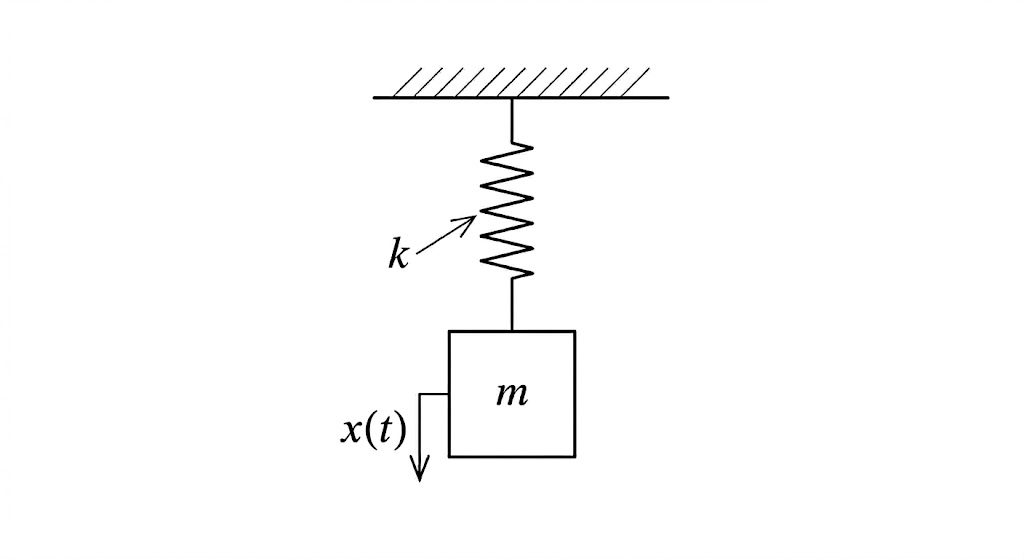

In [ ]:
m, k = 1.0, 4.0
x0, v0 = 1.0, 0.0
t0, tf, h = 0.0, 10.0, 0.1
omega0 = np.sqrt(k / m)

def f_undamped(t, x, v):
    # TODO: implement the acceleration function for the free undamped case
    return 0.0

def exact_undamped(t):
    return x0*np.cos(omega0*t) + (v0/omega0)*np.sin(omega0*t)

t_num, x_num, _ = solver(f_undamped, t0, tf, x0, v0, h)
t_ex = np.linspace(t0, tf, 1000)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(t_ex, exact_undamped(t_ex), "k-", lw=2, label="Analytical")
axes[0].plot(t_num, x_num, "b--o", ms=4, lw=1.4, label="Solver")
axes[0].set_xlabel("t [s]"); axes[0].set_ylabel("x(t) [m]")
axes[0].set_title(f"Free Undamped  (m={m}, k={k}, omega0={omega0:.2f} rad/s)")
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].semilogy(t_num, np.abs(x_num - exact_undamped(t_num)) + 1e-16, "b-o", ms=4, lw=1.4)
axes[1].set_xlabel("t [s]"); axes[1].set_ylabel("|error|")
axes[1].set_title("Global Error (log scale)")
axes[1].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()


---
## 5. Case 2 - Free Damped Oscillation (without gravity)

Here $c$ is the damping coefficient.

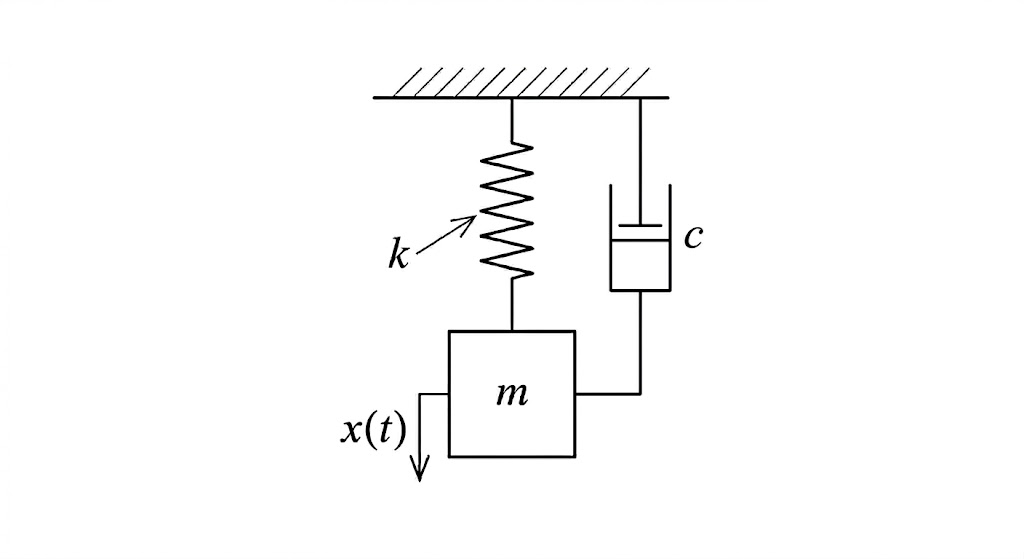

In [ ]:
m, k = 1.0, 4.0
x0, v0 = 1.0, 0.0
t0, tf, h = 0.0, 10.0, 0.05
c = 1.0

def f_damped(t, x, v, c=c):
    #TODO: implement the acceleration function for the free damped case
    return 0.0

t_num, x_num, _ = solver(f_damped, t0, tf, x0, v0, h)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t_num, x_num, lw=2)
ax.axhline(0, color="k", lw=0.8, ls="--")
ax.set_xlabel("t [s]"); ax.set_ylabel("x(t) [m]")
ax.set_title("Free Damped Oscillation - Three Regimes")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 6. Case 3 - Driven Damped Oscillation

Now we add a periodic external force $F(t) = A\cos(\omega t)$:

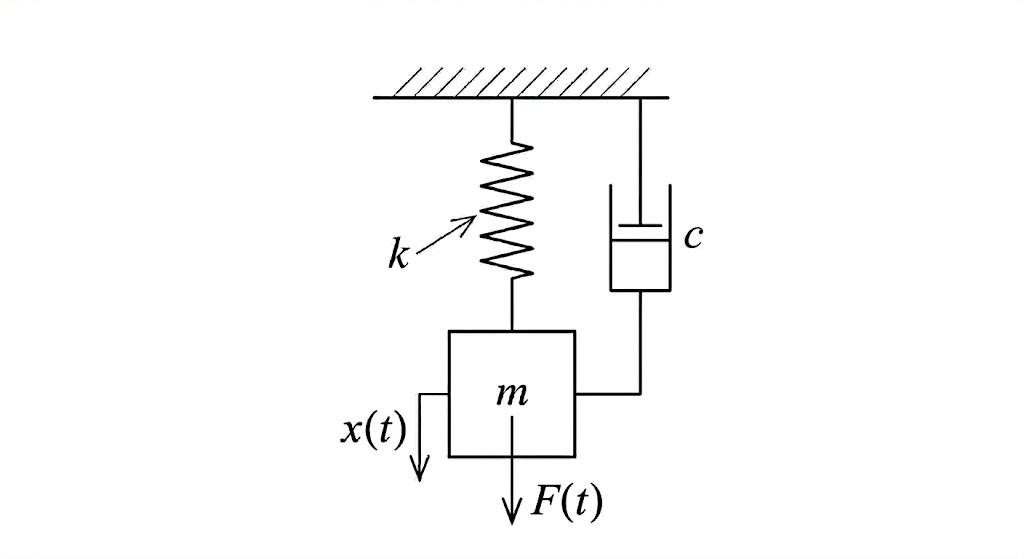

In [ ]:
m, k, c = 1.0, 4.0, 0.4
x0, v0 = 0.0, 0.0
A = 1.0
omega = 1.5
omega0 = np.sqrt(k/m)
t0, tf, h = 0.0, 30.0, 0.05

def f_driven(t, x, v):
    # TODO: implement the acceleration function for the driven damped case
    return 0.0

t_num, x_num, _ = solver(f_driven, t0, tf, x0, v0, h)

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(t_num, x_num, lw=1.6)
ax.set_xlabel("t [s]"); ax.set_ylabel("x(t) [m]")
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## 7. Interactive Explorer

Adjust the sliders to explore the full spring-mass system with damping and an external periodic force:

$$x' = v, \qquad v' = \frac{1}{m}\bigl(A\cos(\omega t) - c\,v - k\,x\bigr)$$

Setting $c = 0$ removes damping; setting $A = 0$ removes the external force.


In [ ]:
out = widgets.Output()

style  = {"description_width": "30px"}
layout = widgets.Layout(width="340px")

m_sl  = widgets.FloatSlider(value=1.0,  min=0.1,  max=5.0,  step=0.1,  description="m",   style=style, layout=layout, continuous_update=False)
k_sl  = widgets.FloatSlider(value=4.0,  min=0.5,  max=20.0, step=0.5,  description="k",   style=style, layout=layout, continuous_update=False)
c_sl  = widgets.FloatSlider(value=0.0,  min=0.0,  max=10.0, step=0.1,  description="c",   style=style, layout=layout, continuous_update=False)
A_sl  = widgets.FloatSlider(value=0.0,  min=0.0,  max=5.0,  step=0.1,  description="A",   style=style, layout=layout, continuous_update=False)
w_sl  = widgets.FloatSlider(value=0.0,  min=0.1,  max=6.0,  step=0.05, description="ω",   style=style, layout=layout, continuous_update=False)
x0_sl = widgets.FloatSlider(value=1.0,  min=-3.0, max=3.0,  step=0.1,  description="x₀",  style=style, layout=layout, continuous_update=False)
v0_sl = widgets.FloatSlider(value=0.0,  min=-5.0, max=5.0,  step=0.1,  description="v₀",  style=style, layout=layout, continuous_update=False)
tf_sl = widgets.FloatSlider(value=20.0, min=5.0,  max=60.0, step=1.0,  description="tf",  style=style, layout=layout, continuous_update=False)

def run_sim(_=None):
    m      = m_sl.value
    k      = k_sl.value
    c      = c_sl.value
    A      = A_sl.value
    omega  = w_sl.value
    x0     = x0_sl.value
    v0     = v0_sl.value
    tf     = tf_sl.value
    omega0 = np.sqrt(k / m)
    h      = 0.02

    def f(t, x, v):
        return (1/m) * (A*np.cos(omega*t) - c*v - k*x)

    t_num, x_num, v_num = solver(f, 0, tf, x0, v0, h)

    with out:
        clear_output(wait=True)
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)

        ax1.plot(t_num, x_num, "b-", lw=2)
        ax1.axhline(0, color="k", lw=0.8, ls="--")
        ax1.set_ylabel("x [m]")
        ax1.set_title("Position")
        ax1.grid(True, alpha=0.3)

        ax2.plot(t_num, v_num, "r-", lw=2)
        ax2.axhline(0, color="k", lw=0.8, ls="--")
        ax2.set_xlabel("t [s]")
        ax2.set_ylabel("v [m/s]")
        ax2.set_title("Velocity")
        ax2.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

for sl in [m_sl, k_sl, c_sl, A_sl, w_sl, x0_sl, v0_sl, tf_sl]:
    sl.observe(run_sim, names="value")

display(widgets.VBox([
    widgets.GridBox(
        [m_sl,  widgets.Label("mass [kg]"),
         k_sl,  widgets.Label("spring stiffness [N/m]"),
         c_sl,  widgets.Label("damping coefficient [N·s/m]"),
         A_sl,  widgets.Label("force amplitude [N]"),
         w_sl,  widgets.Label("driving frequency [rad/s]"),
         x0_sl, widgets.Label("initial position [m]"),
         v0_sl, widgets.Label("initial velocity [m/s]"),
         tf_sl, widgets.Label("simulation end time [s]")],
        layout=widgets.Layout(grid_template_columns="repeat(2, auto)", grid_gap="4px 12px")
    ),
    out
]))
run_sim()
